# 🔬 Concrete Crack Detection & Structural Integrity Assessment
## Hybrid CNN–Transformer + Topology-Constrained Learning

**Pipeline:**
1. Input: Crack Segmentation Dataset (CrackForest + SDNET2018)
2. Data Preprocessing (256×256, augmentation, splits)
3. Hybrid CNN-Transformer Segmentation (EfficientNet-B4(NOW RESNET) + Transformer Bottleneck)
4. Topology-Constrained Loss (Dice + BCE + λ·Topology)
5. Crack Skeletonization (1-pixel skeleton)
6. Graph-Based Crack Modeling (NetworkX)
7. Structural Feature Extraction
8. Structural Integrity Score + Risk Index

**Dataset:** `lakshaymiddha/crack-segmentation-dataset` — add via Kaggle Data panel

> **GPU recommended** (T4 or P100). Runtime ≈ 2–4 hours for 50 epochs.

## Install extra packages

In [1]:
!pip install -q torch==2.3.1+cu118 torchvision==0.18.1+cu118 --index-url https://download.pytorch.org/whl/cu118

In [2]:
!pip install -q segmentation-models-pytorch timm einops

In [3]:
import subprocess
import sys

def install_packages(packages):
    for pkg in packages:
        try:
            print(f"Installing {pkg}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        except subprocess.CalledProcessError as e:
            print(f"❌ Failed to install {pkg}: {e}")
        else:
            print(f"✅ Successfully installed {pkg}")

packages = [
    "segmentation-models-pytorch==0.3.3",
    "timm>=0.9.0",
    "einops>=0.6.0"
]

install_packages(packages)

Installing segmentation-models-pytorch==0.3.3...
✅ Successfully installed segmentation-models-pytorch==0.3.3
Installing timm>=0.9.0...
✅ Successfully installed timm>=0.9.0
Installing einops>=0.6.0...
✅ Successfully installed einops>=0.6.0


## Imports

In [4]:
import os, gc, json, random, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
from copy import deepcopy

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF

import segmentation_models_pytorch as smp
import timm
from einops import rearrange

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from skimage.morphology import skeletonize
from skimage.measure import label, regionprops
import scipy.ndimage as ndi
import networkx as nx


## Reproducibility & Device

In [5]:
def set_seed(seed: int = 42):
    import random, numpy as np, torch
    
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")


Device : cuda
PyTorch: 2.3.1+cu118


## Configuration

In [6]:

class Config:
    # ---- Paths (Kaggle) ----
    DATA_ROOT   = Path("/kaggle/input/datasets/lakshaymiddha/crack-segmentation-dataset")
    WORK_DIR    = Path("/kaggle/working")
    CKPT_DIR    = WORK_DIR / "checkpoints"
    VIZ_DIR     = WORK_DIR / "visualizations"

    # ---- Image ----
    IMG_SIZE    = 256
    IN_CHANNELS = 3

    # ---- Data split ----
    VAL_RATIO   = 0.15
    TEST_RATIO  = 0.10

    # ---- Training ----
    EPOCHS      = 20
    BATCH_SIZE  = 16
    LR          = 2e-4
    MIN_LR      = 1e-6
    WEIGHT_DECAY= 1e-5
    GRAD_CLIP   = 5.0

    # ---- Loss weights ----
    LAMBDA_DICE = 1.0
    LAMBDA_BCE  = 1.0
    LAMBDA_TOPO = 0.5

    # ---- Model ----
 
    ENCODER     = "resnet34"       # ✅ stable backbone
    ENC_WEIGHTS = "imagenet"
    N_HEADS     = 8
    D_MODEL     = 512
    N_LAYERS    = 4

    # ---- SI scoring ----
    RISK_THRESHOLDS = {"Low": 0.25, "Moderate": 0.50, "High": 0.75}

cfg = Config()
cfg.CKPT_DIR.mkdir(parents=True, exist_ok=True)
cfg.VIZ_DIR.mkdir(parents=True, exist_ok=True)


## Dataset Discovery

In [7]:

def collect_image_mask_pairs(root: Path):
    """
    The crack-segmentation-dataset folder structure:
      root/
        images/  *.jpg / *.png
        masks/   *.jpg / *.png   (same stem, binary)
    Falls back to a recursive search if structure differs.
    """
    img_dir  = root / "images"
    mask_dir = root / "masks"

    if img_dir.exists() and mask_dir.exists():
        imgs  = sorted(img_dir.glob("*.[jp][pn]g"))
        masks = []
        for p in imgs:
            m = mask_dir / p.name
            if not m.exists():
                m = mask_dir / (p.stem + ".png")
            masks.append(m if m.exists() else None)
        pairs = [(i, m) for i, m in zip(imgs, masks) if m is not None]
        print(f"Found {len(pairs)} image-mask pairs in {root}")
        return pairs

    # Recursive fallback  ── look for 'image'/'mask' sibling dirs
    pairs = []
    for img_path in sorted(root.rglob("*.jpg")) + sorted(root.rglob("*.png")):
        if "mask" in img_path.parts or "label" in img_path.parts:
            continue
        # Try to find matching mask
        for tag in ("mask", "label", "gt"):
            mask_path = Path(str(img_path).replace("image", tag)
                                          .replace("Image", tag))
            if mask_path.exists():
                pairs.append((img_path, mask_path))
                break
    print(f"Recursive search: {len(pairs)} pairs")
    return pairs

all_pairs = collect_image_mask_pairs(cfg.DATA_ROOT)


Recursive search: 45192 pairs


## Train / Val / Test Split

In [8]:

indices    = list(range(len(all_pairs)))
train_idx, test_idx = train_test_split(indices, test_size=cfg.TEST_RATIO,  random_state=42)
train_idx, val_idx  = train_test_split(train_idx, test_size=cfg.VAL_RATIO/(1-cfg.TEST_RATIO), random_state=42)

train_pairs = [all_pairs[i] for i in train_idx]
val_pairs   = [all_pairs[i] for i in val_idx]
test_pairs  = [all_pairs[i] for i in test_idx]

print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")


Train: 33893 | Val: 6779 | Test: 4520


## Dataset Class

In [9]:

class CrackDataset(Dataset):
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, pairs, img_size=256, augment=False):
        self.pairs    = pairs
        self.img_size = img_size
        self.augment  = augment

    def __len__(self): return len(self.pairs)

    def _load(self, img_path, mask_path):
        img  = cv2.imread(str(img_path))
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img  = cv2.resize(img,  (self.img_size, self.img_size))

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype(np.uint8)
        return img, mask

    def _augment(self, img, mask):
        img  = Image.fromarray(img)
        mask = Image.fromarray(mask)

        # Flip
        if random.random() > 0.5:
            img, mask = TF.hflip(img), TF.hflip(mask)
        if random.random() > 0.5:
            img, mask = TF.vflip(img), TF.vflip(mask)

        # Rotation
        if random.random() > 0.5:
            angle = random.choice([90, 180, 270])
            img   = TF.rotate(img,  angle)
            mask  = TF.rotate(mask, angle)

        # Color jitter (image only)
        if random.random() > 0.3:
            img = TF.adjust_brightness(img, random.uniform(0.7, 1.3))
            img = TF.adjust_contrast(img,   random.uniform(0.7, 1.3))

        return np.array(img), np.array(mask)

    def __getitem__(self, idx):
        img, mask = self._load(*self.pairs[idx])
        if self.augment:
            img, mask = self._augment(img, mask)

        img  = img.astype(np.float32) / 255.0
        img  = (img - np.array(self.MEAN)) / np.array(self.STD)
        img  = torch.from_numpy(img.transpose(2, 0, 1)).float()
        mask = torch.from_numpy(mask).long()
        return img, mask

train_ds = CrackDataset(train_pairs, cfg.IMG_SIZE, augment=True)
val_ds   = CrackDataset(val_pairs,   cfg.IMG_SIZE, augment=False)
test_ds  = CrackDataset(test_pairs,  cfg.IMG_SIZE, augment=False)

train_dl = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)

print(f"Batches — Train: {len(train_dl)}, Val: {len(val_dl)}, Test: {len(test_dl)}")


Batches — Train: 2119, Val: 424, Test: 283


## Visualise Samples

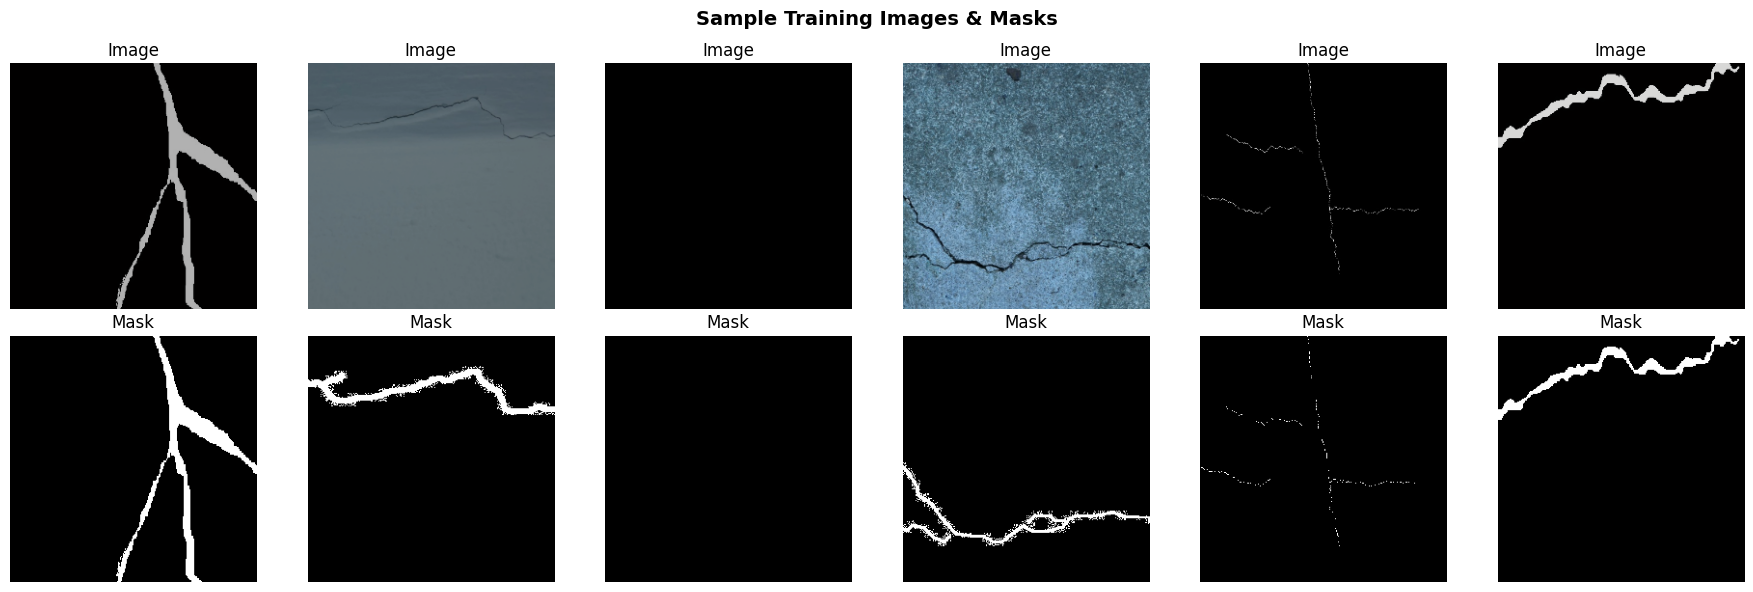

In [10]:

def denorm(t, mean=CrackDataset.MEAN, std=CrackDataset.STD):
    m = torch.tensor(mean).view(3,1,1)
    s = torch.tensor(std ).view(3,1,1)
    return (t * s + m).clamp(0, 1)

imgs, masks = next(iter(train_dl))
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i in range(6):
    axes[0, i].imshow(denorm(imgs[i]).permute(1, 2, 0).numpy())
    axes[0, i].set_title("Image"); axes[0, i].axis("off")
    axes[1, i].imshow(masks[i].numpy(), cmap="gray")
    axes[1, i].set_title("Mask"); axes[1, i].axis("off")
plt.suptitle("Sample Training Images & Masks", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(cfg.VIZ_DIR / "samples.png", dpi=120)
plt.show()


## Transformer Bottleneck

In [11]:

class TransformerBottleneck(nn.Module):
    """
    Multi-head self-attention bottleneck inserted between CNN encoder
    and decoder.  Spatial positions become sequence tokens.
    """
    def __init__(self, in_channels: int, d_model: int = 512,
                 n_heads: int = 8, n_layers: int = 4, dropout: float = 0.1):
        super().__init__()
        self.proj_in  = nn.Conv2d(in_channels, d_model, 1)
        self.proj_out = nn.Conv2d(d_model, in_channels, 1)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True,
            norm_first=True                     # pre-norm for stability
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        B, C, H, W = x.shape
        z = self.proj_in(x)                     # (B, d_model, H, W)
        z = rearrange(z, "b c h w -> b (h w) c")  # (B, HW, d_model)
        z = self.transformer(z)
        z = self.norm(z)
        z = rearrange(z, "b (h w) c -> b c h w", h=H, w=W)
        z = self.proj_out(z)
        return x + z                            # residual


## Hybrid CNN-Transformer Model

In [12]:

class HybridCNNTransformer(nn.Module):
    """
    CNN Encoder  (EfficientNet-B4 via SMP)
    Transformer Bottleneck  (on deepest feature map)
    UNet++ Decoder  (produces segmentation mask)
    """
    def __init__(self, cfg):
        super().__init__()
        # ---- Base UNet++ from SMP ----
        self.base = smp.UnetPlusPlus(
            encoder_name     = cfg.ENCODER,
            encoder_weights  = cfg.ENC_WEIGHTS,
            in_channels      = cfg.IN_CHANNELS,
            classes          = 1,
            activation       = None
        )
        # ---- Insert transformer at bottleneck ----
        # EfficientNet-B4 deepest feature map channels = 448
        enc_out_channels = self.base.encoder.out_channels[-1]
        self.tformer = TransformerBottleneck(
            in_channels = enc_out_channels,
            d_model     = cfg.D_MODEL,
            n_heads     = cfg.N_HEADS,
            n_layers    = cfg.N_LAYERS,
        )

    def forward(self, x):
        # Encode
        features = self.base.encoder(x)
        # Apply transformer on deepest feature map
        features[-1] = self.tformer(features[-1])
        # Decode
        decoder_out = self.base.decoder(*features)
        mask        = self.base.segmentation_head(decoder_out)
        return mask.squeeze(1)           # (B, H, W) raw logits

model = HybridCNNTransformer(cfg).to(DEVICE)

# Parameter count
total_p    = sum(p.numel() for p in model.parameters())
trainable_p= sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_p/1e6:.2f} M")
print(f"Trainable params: {trainable_p/1e6:.2f} M")


Total params    : 39.21 M
Trainable params: 39.21 M


## Soft-Skeleton for Topology Loss

In [13]:

def soft_skeleton(x: torch.Tensor, iters: int = 10) -> torch.Tensor:
    """
    Differentiable approximation of morphological skeletonization.
    Uses iterative min-pooling subtraction (Shit et al., 2021 inspired).
    x : (B, 1, H, W) probabilities in [0,1]
    """
    x = x.clone()
    skel = torch.zeros_like(x)
    for _ in range(iters):
        eroded = -F.max_pool2d(-x, kernel_size=3, stride=1, padding=1)  # min-pool
        delta  = F.relu(x - eroded)
        skel   = skel + F.relu(delta - skel)
        x      = eroded
    return skel

class TopologyLoss(nn.Module):
    """
    Topology-aware loss combining:
      1. Skeleton continuity  – skeleton of pred should overlap GT skeleton
      2. Clique penalty       – penalises disconnected components in prediction
    """
    def __init__(self, skel_iters: int = 10):
        super().__init__()
        self.skel_iters = skel_iters

    def forward(self, pred_prob: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        """
        pred_prob : (B, H, W) sigmoid probabilities
        target    : (B, H, W) binary float
        """
        p = pred_prob.unsqueeze(1)   # (B,1,H,W)
        t = target.unsqueeze(1).float()

        pred_skel = soft_skeleton(p,   self.skel_iters)
        gt_skel   = soft_skeleton(t,   self.skel_iters)

        # Skeleton recall: GT skeleton covered by prediction?
        skel_recall = (gt_skel * p).sum() / (gt_skel.sum() + 1e-6)
        # Skeleton precision: pred skeleton covered by GT?
        skel_prec   = (pred_skel * t).sum() / (pred_skel.sum() + 1e-6)

        topo_loss = 1.0 - (skel_recall + skel_prec) / 2.0
        return topo_loss

class CombinedLoss(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.dice_loss = smp.losses.DiceLoss(mode="binary", smooth=1.0)
        self.bce_loss  = nn.BCEWithLogitsLoss()
        self.topo_loss = TopologyLoss(skel_iters=10)
        self.ld, self.lb, self.lt = cfg.LAMBDA_DICE, cfg.LAMBDA_BCE, cfg.LAMBDA_TOPO

    def forward(self, logits, target):
        target_f   = target.float()
        pred_prob  = torch.sigmoid(logits)

        loss_dice  = self.dice_loss(logits.unsqueeze(1), target.unsqueeze(1))
        loss_bce   = self.bce_loss(logits, target_f)
        loss_topo  = self.topo_loss(pred_prob, target_f)

        total = self.ld * loss_dice + self.lb * loss_bce + self.lt * loss_topo
        return total, loss_dice.item(), loss_bce.item(), loss_topo.item()

criterion = CombinedLoss(cfg)


## Metrics

In [14]:

def compute_metrics(pred_logits, targets, thresh=0.5):
    probs  = torch.sigmoid(pred_logits)
    preds  = (probs > thresh).float().cpu().numpy().flatten()
    labels = targets.float().cpu().numpy().flatten()

    tp  = ((preds == 1) & (labels == 1)).sum()
    fp  = ((preds == 1) & (labels == 0)).sum()
    fn  = ((preds == 0) & (labels == 1)).sum()
    tn  = ((preds == 0) & (labels == 0)).sum()

    eps   = 1e-6
    dice  = 2*tp / (2*tp + fp + fn + eps)
    iou   = tp   / (tp + fp + fn + eps)
    prec  = tp   / (tp + fp + eps)
    rec   = tp   / (tp + fn + eps)
    f1    = 2*(prec*rec) / (prec + rec + eps)
    return {"dice": dice, "iou": iou, "precision": prec, "recall": rec, "f1": f1}


## Optimiser & Scheduler

In [15]:

optimizer = torch.optim.AdamW(model.parameters(),
                               lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cfg.EPOCHS, eta_min=cfg.MIN_LR)

# Mixed-precision scaler
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


In [16]:
#STARTING AFTER FAIL


## Training Loop

In [17]:

history = {"train_loss":[], "val_loss":[], "val_dice":[], "val_iou":[]}
best_val_dice = 0.0

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, total_dice, total_iou = 0, 0, 0
    with torch.set_grad_enabled(training):
        for imgs, masks in tqdm(loader, desc="train" if training else "val ", leave=False):
            imgs  = imgs .to(DEVICE)
            masks = masks.to(DEVICE)

            with torch.cuda.amp.autocast(enabled=False):
                logits                       = model(imgs)
                loss, l_d, l_b, l_t         = criterion(logits, masks)

         
            if training:
                optimizer.zero_grad()
                loss.backward()   # ← use normal backward
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
                optimizer.step()

            m = compute_metrics(logits.detach(), masks)
            total_loss += loss.item()
            total_dice += m["dice"]
            total_iou  += m["iou"]

    n = len(loader)
    return total_loss/n, total_dice/n, total_iou/n

print("=" * 60)
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Val Dice':>8} | {'Val IoU':>7} | {'LR':>8}")
print("=" * 60)

for epoch in range(1, cfg.EPOCHS + 1):
    tr_loss, tr_dice, tr_iou = run_epoch(train_dl, training=True)
    vl_loss, vl_dice, vl_iou = run_epoch(val_dl,   training=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"]  .append(vl_loss)
    history["val_dice"]  .append(vl_dice)
    history["val_iou"]   .append(vl_iou)

    cur_lr = optimizer.param_groups[0]["lr"]
    print(f"{epoch:>5} | {tr_loss:>10.4f} | {vl_loss:>8.4f} | "
          f"{vl_dice:>8.4f} | {vl_iou:>7.4f} | {cur_lr:.2e}")

    if vl_dice > best_val_dice:
        best_val_dice = vl_dice
        torch.save({"epoch": epoch,
                    "model_state": model.state_dict(),
                    "optim_state": optimizer.state_dict(),
                    "val_dice":    vl_dice},
                   cfg.CKPT_DIR / "best_model.pth")
        print(f"  ✓ Saved best model (dice={best_val_dice:.4f})")

print(f"\nBest Val Dice: {best_val_dice:.4f}")


Epoch | Train Loss | Val Loss | Val Dice | Val IoU |       LR


train:   0%|          | 0/2119 [00:00<?, ?it/s]

val :   0%|          | 0/424 [00:00<?, ?it/s]

    1 |     0.4836 |   0.3815 |   0.7913 |  0.6584 | 1.99e-04
  ✓ Saved best model (dice=0.7913)


train:   0%|          | 0/2119 [00:00<?, ?it/s]

...

val :   0%|          | 0/424 [00:00<?, ?it/s]

   19 |     0.3364 |   0.3355 |   0.8141 |  0.6893 | 2.23e-06


train:   0%|          | 0/2119 [00:00<?, ?it/s]

val :   0%|          | 0/424 [00:00<?, ?it/s]

   20 |     0.3364 |   0.3344 |   0.8148 |  0.6903 | 1.00e-06
  ✓ Saved best model (dice=0.8148)

Best Val Dice: 0.8148


## Training Curves

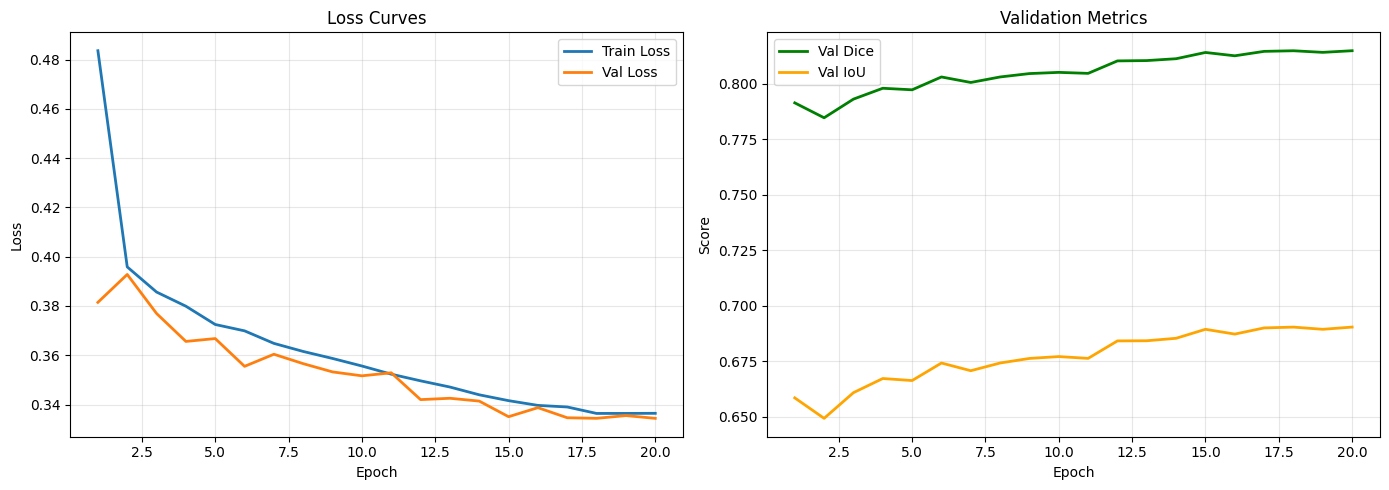

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eps = range(1, cfg.EPOCHS + 1)

axes[0].plot(eps, history["train_loss"], label="Train Loss", lw=2)
axes[0].plot(eps, history["val_loss"],   label="Val Loss",   lw=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(eps, history["val_dice"], label="Val Dice", lw=2, color="green")
axes[1].plot(eps, history["val_iou"],  label="Val IoU",  lw=2, color="orange")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].set_title("Validation Metrics"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(cfg.VIZ_DIR / "training_curves.png", dpi=120)
plt.show()


## Load Best Model & Test Evaluation

In [19]:

ckpt = torch.load(cfg.CKPT_DIR / "best_model.pth", map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best model from epoch {ckpt['epoch']} (dice={ckpt['val_dice']:.4f})")

model.eval()
all_metrics = []
with torch.no_grad():
    for imgs, masks in tqdm(test_dl, desc="Testing"):
        logits = model(imgs.to(DEVICE))
        m = compute_metrics(logits, masks.to(DEVICE))
        all_metrics.append(m)

test_results = {k: np.mean([m[k] for m in all_metrics]) for k in all_metrics[0]}
print("\n── Test Set Results ──────────────────────────")
for k, v in test_results.items():
    print(f"  {k:<12}: {v:.4f}")


Loaded best model from epoch 20 (dice=0.8148)


Testing:   0%|          | 0/283 [00:00<?, ?it/s]


── Test Set Results ──────────────────────────
  dice        : 0.8136
  iou         : 0.6887
  precision   : 0.8109
  recall      : 0.8184
  f1          : 0.8136


## Crack Skeletonization

In [20]:

def skeletonize_mask(binary_mask: np.ndarray) -> np.ndarray:
    """
    Convert a binary segmentation mask to a 1-pixel-wide skeleton.
    binary_mask : (H, W) uint8 {0,1}
    """
    return skeletonize(binary_mask.astype(bool)).astype(np.uint8)

def get_skeleton_stats(skeleton: np.ndarray):
    """Count pixels, endpoints, branch-points in the skeleton."""
    skel_pixels = skeleton.sum()
    if skel_pixels == 0:
        return {"total_pixels": 0, "endpoints": 0, "branch_points": 0}

    # Neighbour count for each skeleton pixel
    kernel  = np.ones((3, 3), dtype=np.uint8)
    nbcount = cv2.filter2D(skeleton.astype(np.uint8), -1, kernel) * skeleton
    nbcount = nbcount - 1    # subtract self

    endpoints     = (nbcount == 1).sum()
    branch_points = (nbcount >= 3).sum()
    return {"total_pixels": int(skel_pixels),
            "endpoints":    int(endpoints),
            "branch_points":int(branch_points)}


## Graph-Based Crack Modelling

In [26]:

def build_crack_graph(skeleton: np.ndarray):
    """
    Build a NetworkX graph from the crack skeleton.
    Nodes = branch points / endpoints
    Edges = crack segments between nodes (weighted by pixel length)
    """
    if skeleton.sum() == 0:
        return nx.Graph()

    kernel   = np.ones((3, 3), dtype=np.uint8)
    nbcount  = cv2.filter2D(skeleton.astype(np.uint8), -1, kernel) * skeleton - 1
    node_map = ((nbcount == 1) | (nbcount >= 3)).astype(np.uint8)  # endpoints & branches

    # Label connected skeleton pixels
    labeled, n_comp = label(skeleton, connectivity=2, return_num=True)
    G = nx.Graph()

    node_pts = np.argwhere(node_map > 0)
    node_ids = {tuple(pt): i for i, pt in enumerate(node_pts)}
    for pid, pt in enumerate(node_pts):
        G.add_node(pid, pos=(int(pt[1]), int(pt[0])), kind="branch" if nbcount[pt[0], pt[1]] >= 3 else "endpoint")

    # BFS from each node along skeleton to find neighbours
    def bfs_trace(start, visited):
        stack  = [(start, 0)]
        path   = []
        while stack:
            cur, dist = stack.pop()
            if cur in visited: continue
            visited.add(cur)
            path.append(cur)
            r, c = cur
            for dr in [-1, 0, 1]:
                for dc in [-1, 0, 1]:
                    if dr == 0 and dc == 0: continue
                    nr, nc = r+dr, c+dc
                    if 0 <= nr < skeleton.shape[0] and 0 <= nc < skeleton.shape[1]:
                        if skeleton[nr, nc] and (nr, nc) not in visited:
                            nb = (nr, nc)
                            if nb in node_ids and nb != start:
                                return node_ids[start], node_ids[nb], dist+1
                            stack.append((nb, dist+1))
        return None

    visited = set()
    for pt in node_pts:
        key = tuple(pt)
        result = bfs_trace(key, set())
        if result:
            u, v, w = result
            if not G.has_edge(u, v):
                G.add_edge(u, v, weight=w)

    return G

def extract_structural_features(G: nx.Graph, skeleton: np.ndarray,
                                 pixel_size_mm: float = 1.0) -> dict:
    """
    Extract the 4 structural features shown in the pipeline diagram.
    """
    feats = {}

    # 1. Total Crack Length (pixels → mm)
    feats["total_crack_length_px"] = int(skeleton.sum())
    feats["total_crack_length_mm"] = feats["total_crack_length_px"] * pixel_size_mm

    # 2. Number of Branches (nodes with degree ≥ 3)
    feats["num_branches"] = sum(1 for n, d in G.degree() if d >= 3)

    # 3. Longest Path (approximate via longest shortest-path between endpoints)
    endpoints = [n for n, d in G.degree() if d == 1]
    if len(endpoints) >= 2 and nx.is_connected(G) and len(G.nodes) > 0:
        try:
            longest = max(
                nx.shortest_path_length(G, u, v, weight="weight")
                for u in endpoints[:10] for v in endpoints[:10] if u != v
            )
        except Exception:
            longest = 0
    else:
        longest = 0
    feats["longest_path_px"] = longest
    feats["longest_path_mm"] = longest * pixel_size_mm

    # 4. Graph Diameter
    if len(G.nodes) > 1 and nx.is_connected(G):
        try:
            feats["graph_diameter"] = nx.diameter(G)
        except Exception:
            feats["graph_diameter"] = 0
    else:
        feats["graph_diameter"] = len(G.nodes) if len(G.nodes) <= 1 else 0

    # Bonus metrics
    feats["num_nodes"] = G.number_of_nodes()
    feats["num_edges"] = G.number_of_edges()

    return feats


## Structural Integrity Score (SI)

In [30]:

def compute_si_score(pred_logit_np: np.ndarray,
                     target_np:     np.ndarray,
                     feats:         dict) -> dict:
    """
    Combines Pixel Metrics (Dice, BCE) and Topology Metrics
    (Connectivity, Consistency) into a final SI score and Risk Index.

    SI ∈ [0,1]:  higher → more damage / lower integrity
    """
    pred_prob = torch.sigmoid(torch.tensor(pred_logit_np)).numpy()
    pred_bin  = (pred_prob > 0.5).astype(np.uint8)
    target_b  = target_np.astype(np.uint8)

    # ---- Pixel Metrics ----
    tp  = ((pred_bin == 1) & (target_b == 1)).sum()
    fp  = ((pred_bin == 1) & (target_b == 0)).sum()
    fn  = ((pred_bin == 0) & (target_b == 1)).sum()
    eps = 1e-6
    dice_score = 2*tp / (2*tp + fp + fn + eps)   # 1 = perfect overlap

    # ---- Topology Metrics ----
    pred_skel = skeletonize_mask(pred_bin)
    gt_skel   = skeletonize_mask(target_b)

    # Connectivity: fraction of GT skeleton covered by pred skeleton
    connectivity = (pred_skel * gt_skel).sum() / (gt_skel.sum() + eps)
    # Consistency: fraction of pred connected components that overlap GT
    pred_cc, n_pred = label(pred_bin, connectivity=2, return_num=True)
    gt_cc,   n_gt   = label(target_b, connectivity=2, return_num=True)
    consistent = sum(1 for i in range(1, n_pred+1)
                     if (target_b[pred_cc == i]).sum() > 0)
    consistency = consistent / max(n_pred, 1)

    # ---- Severity from structural features ----
    # Normalise crack length to [0,1] using a 10k-pixel upper bound
    norm_len    = min(feats.get("total_crack_length_px", 0) / 10000, 1.0)
    norm_branch = min(feats.get("num_branches", 0) / 20, 1.0)

    # ---- SI Score ----
    si_score = (
        0.30 * (1 - dice_score)   +   # pixel damage extent
        0.20 * (1 - connectivity)  +   # topological continuity
        0.20 * (1 - consistency)   +   # structural consistency
        0.15 * norm_len            +   # crack length severity
        0.15 * norm_branch             # branching complexity
    )
    si_score = float(np.clip(si_score, 0, 1))

    if si_score < cfg.RISK_THRESHOLDS["Low"]:
        risk = "Low"
    elif si_score < cfg.RISK_THRESHOLDS["Moderate"]:
        risk = "Moderate"
    elif si_score < cfg.RISK_THRESHOLDS["High"]:
        risk = "High"
    else:
        risk = "Critical"

    return {
        "dice_score":    round(float(dice_score),    4),
        "connectivity":  round(float(connectivity),  4),
        "consistency":   round(float(consistency),   4),
        "norm_length":   round(float(norm_len),      4),
        "norm_branches": round(float(norm_branch),   4),
        "si_score":      round(si_score, 4),
        "risk_index":    risk,
    }


## Full Inference Pipeline

In [41]:

def analyse_single_image(img_path: str, mask_path: str = None,
                          pixel_size_mm: float = 1.0):
    """
    End-to-end: load → preprocess → segment → skeletonize → graph → SI score.
    Returns a rich dict of results.
    """
    # Load & preprocess
    img_raw = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img_r   = cv2.resize(img_raw, (cfg.IMG_SIZE, cfg.IMG_SIZE))
    img_t   = ((img_r.astype(np.float32) / 255.0 - np.array(CrackDataset.MEAN))
                / np.array(CrackDataset.STD))
    tensor  = torch.from_numpy(img_t.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)

    # Segmentation
    model.eval()
    with torch.no_grad():
        logit = model(tensor).cpu().squeeze(0).numpy()   # (H,W) raw logit
    pred_prob = 1 / (1 + np.exp(-logit))
    pred_bin  = (pred_prob > 0.5).astype(np.uint8)

    # Load ground truth if available
    if mask_path:
        gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        gt = cv2.resize(gt, (cfg.IMG_SIZE, cfg.IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        gt = (gt > 127).astype(np.uint8)
    else:
        gt = None

    # Skeletonization
    skeleton = skeletonize_mask(pred_bin)
    skel_stats = get_skeleton_stats(skeleton)

    # Graph
    G = build_crack_graph(skeleton)
    feats = extract_structural_features(G, skeleton, pixel_size_mm)

    # SI Score
    si = compute_si_score(logit, gt if gt is not None else pred_bin, feats)

    return {
        "image":        img_r,
        "pred_prob":    pred_prob,
        "pred_bin":     pred_bin,
        "skeleton":     skeleton,
        "gt_mask":      gt,
        "graph":        G,
        "skel_stats":   skel_stats,
        "features":     feats,
        "si_result":    si,
    }


## Batch Test Inference & Visualisation

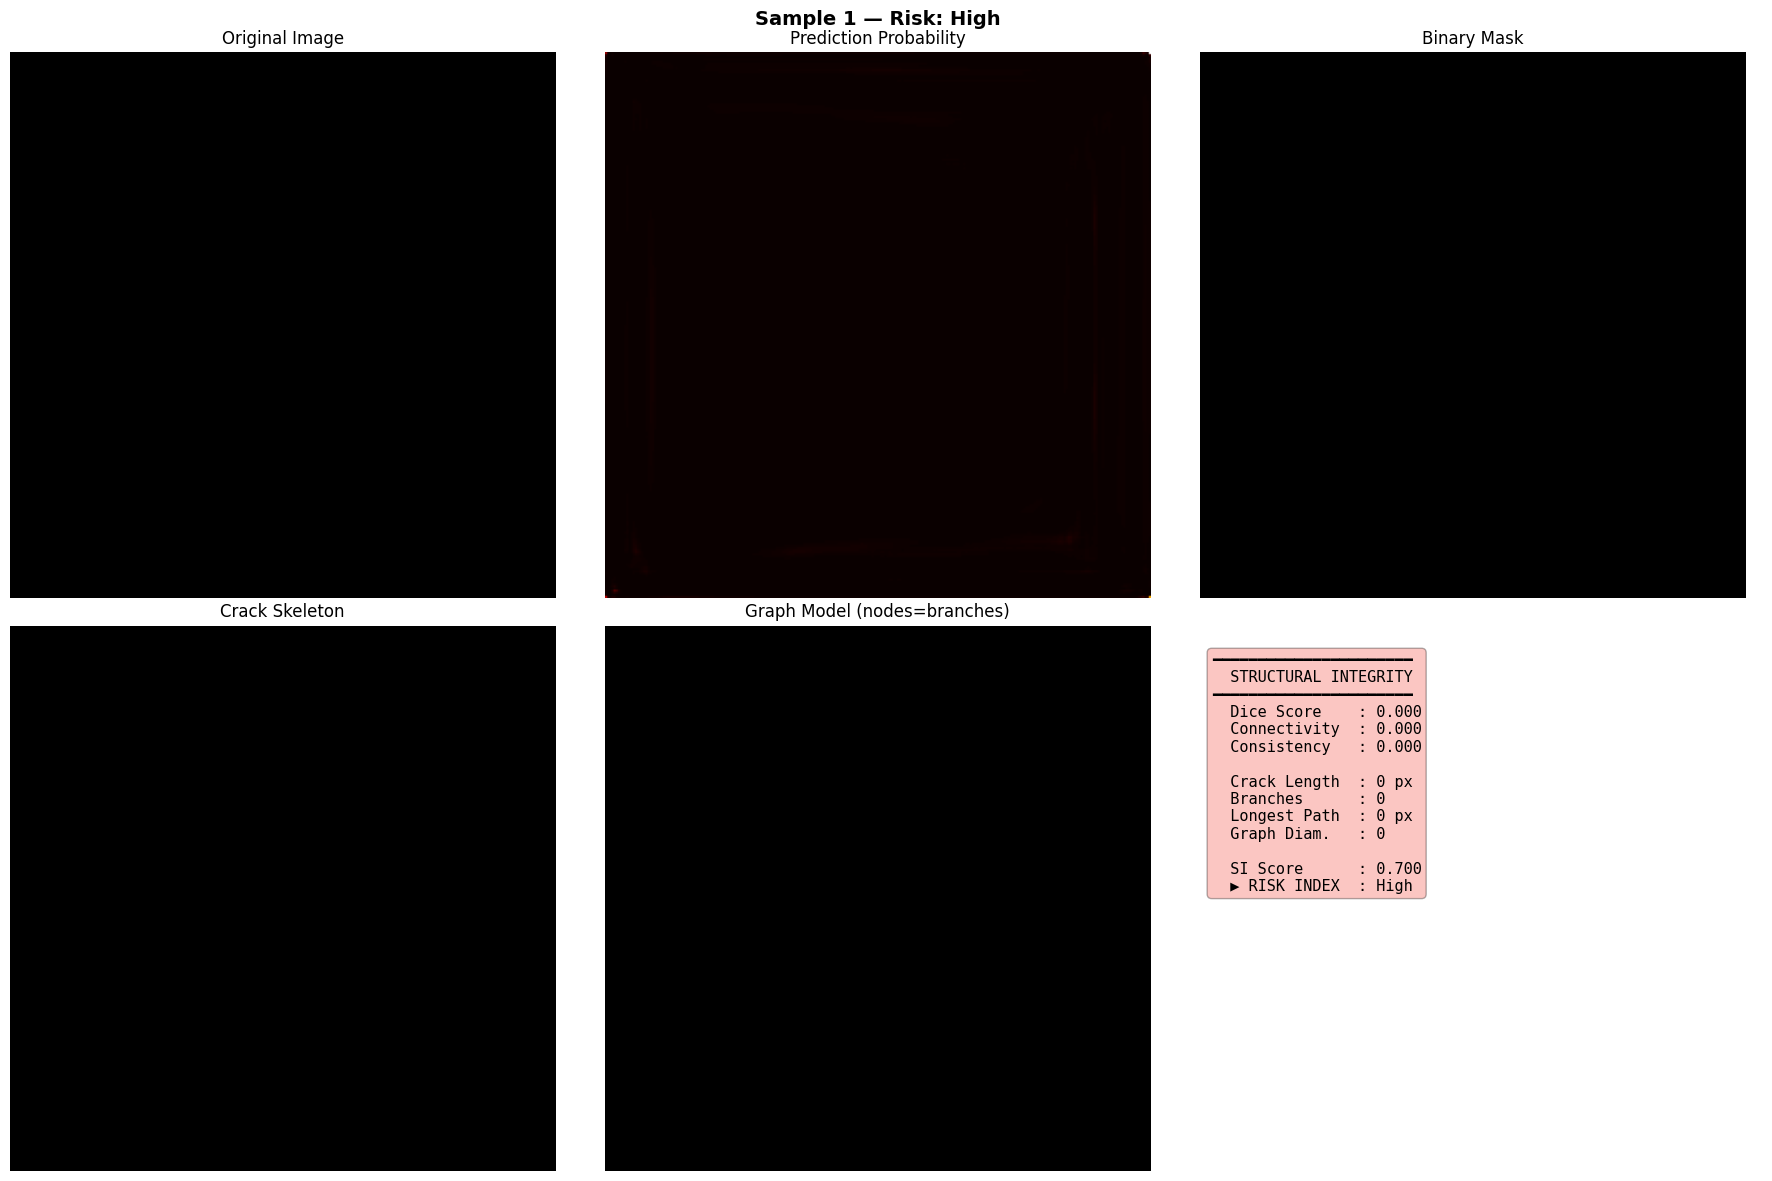

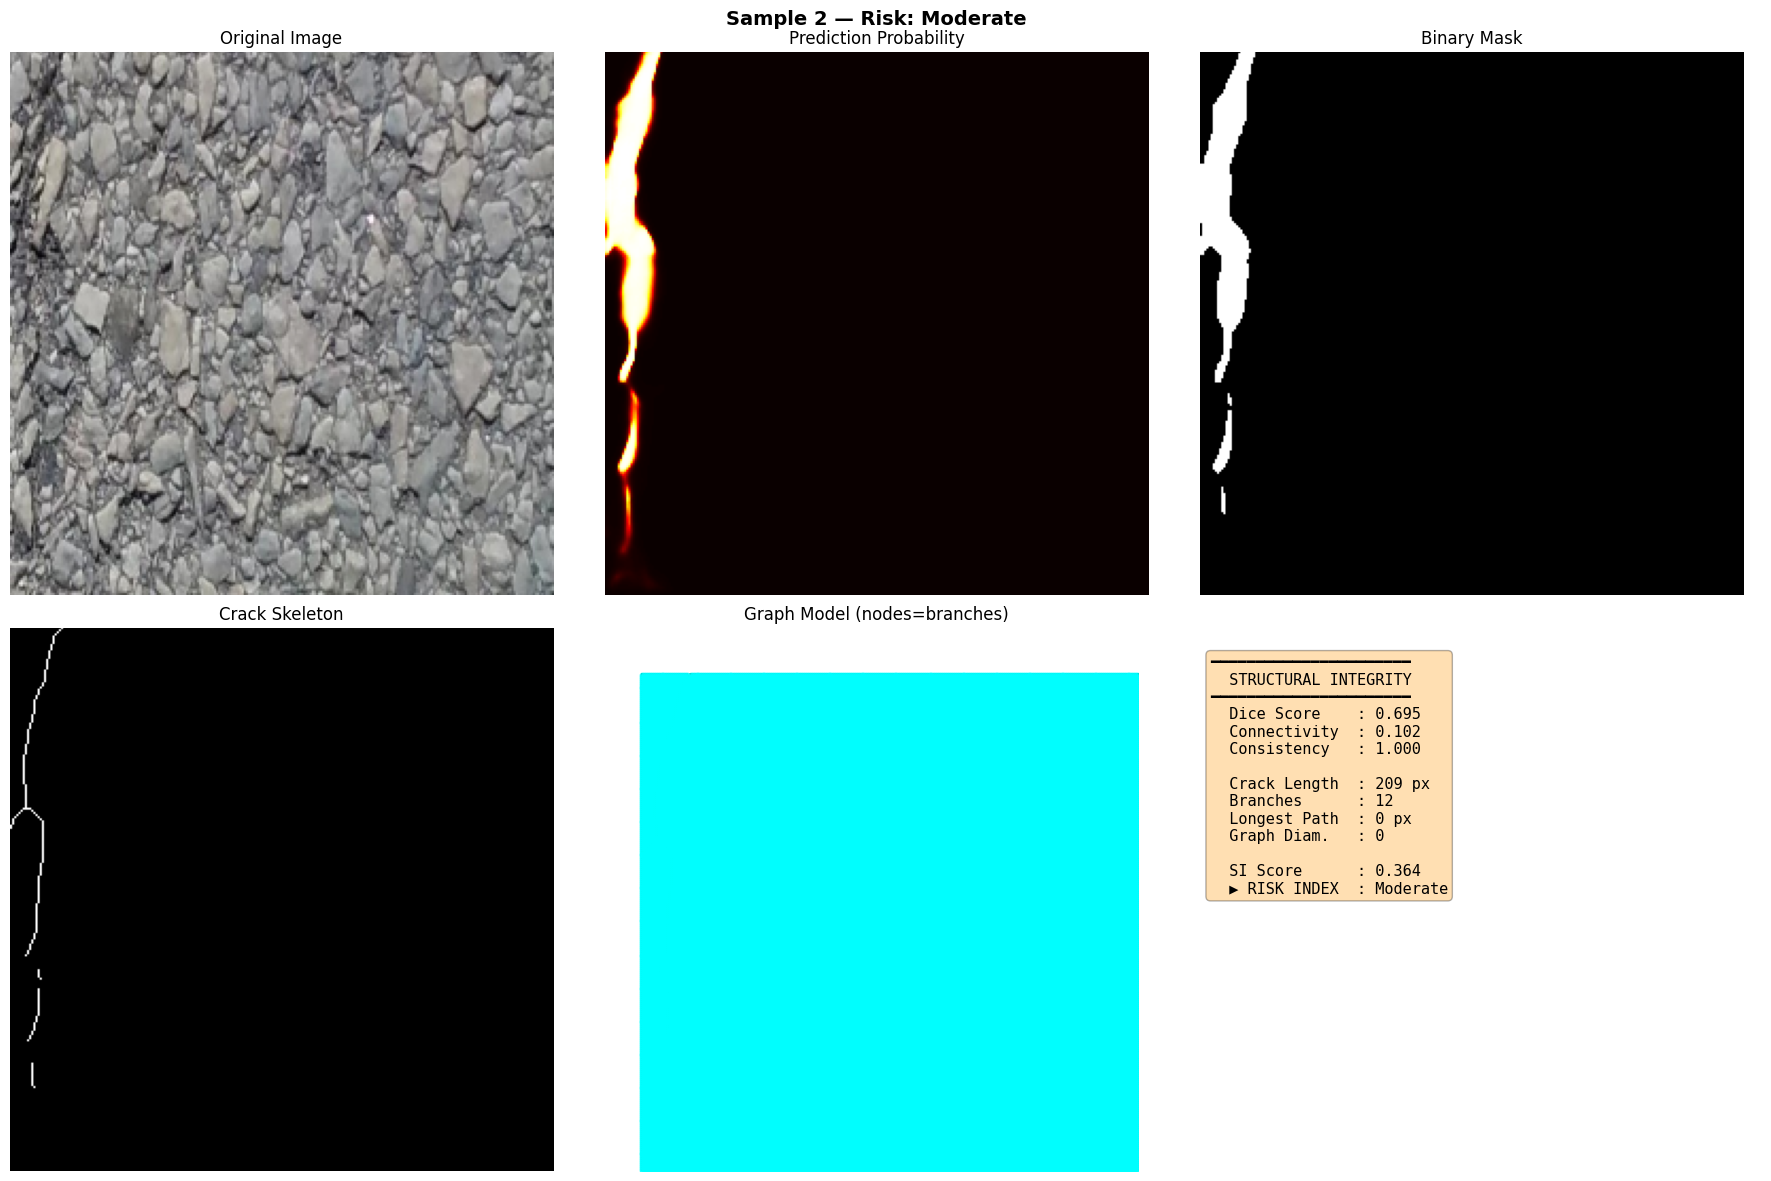

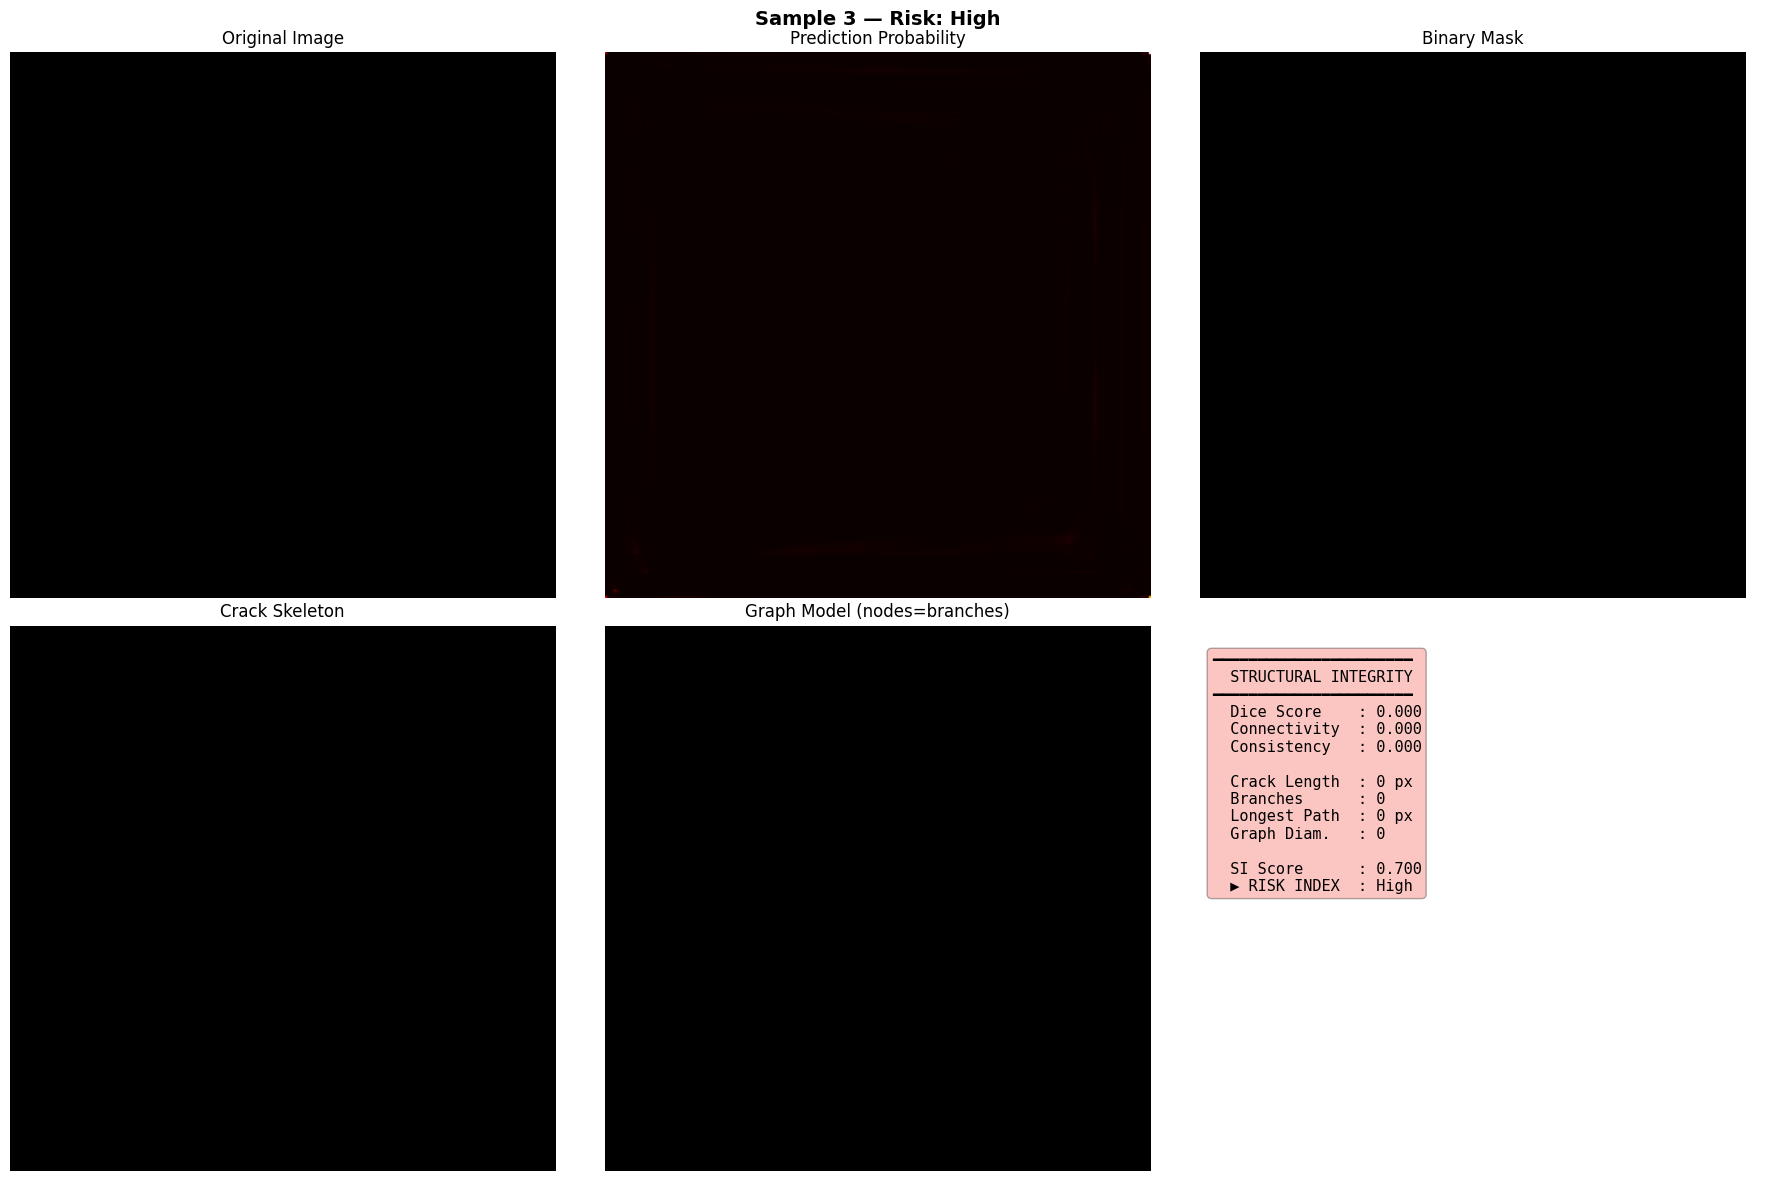

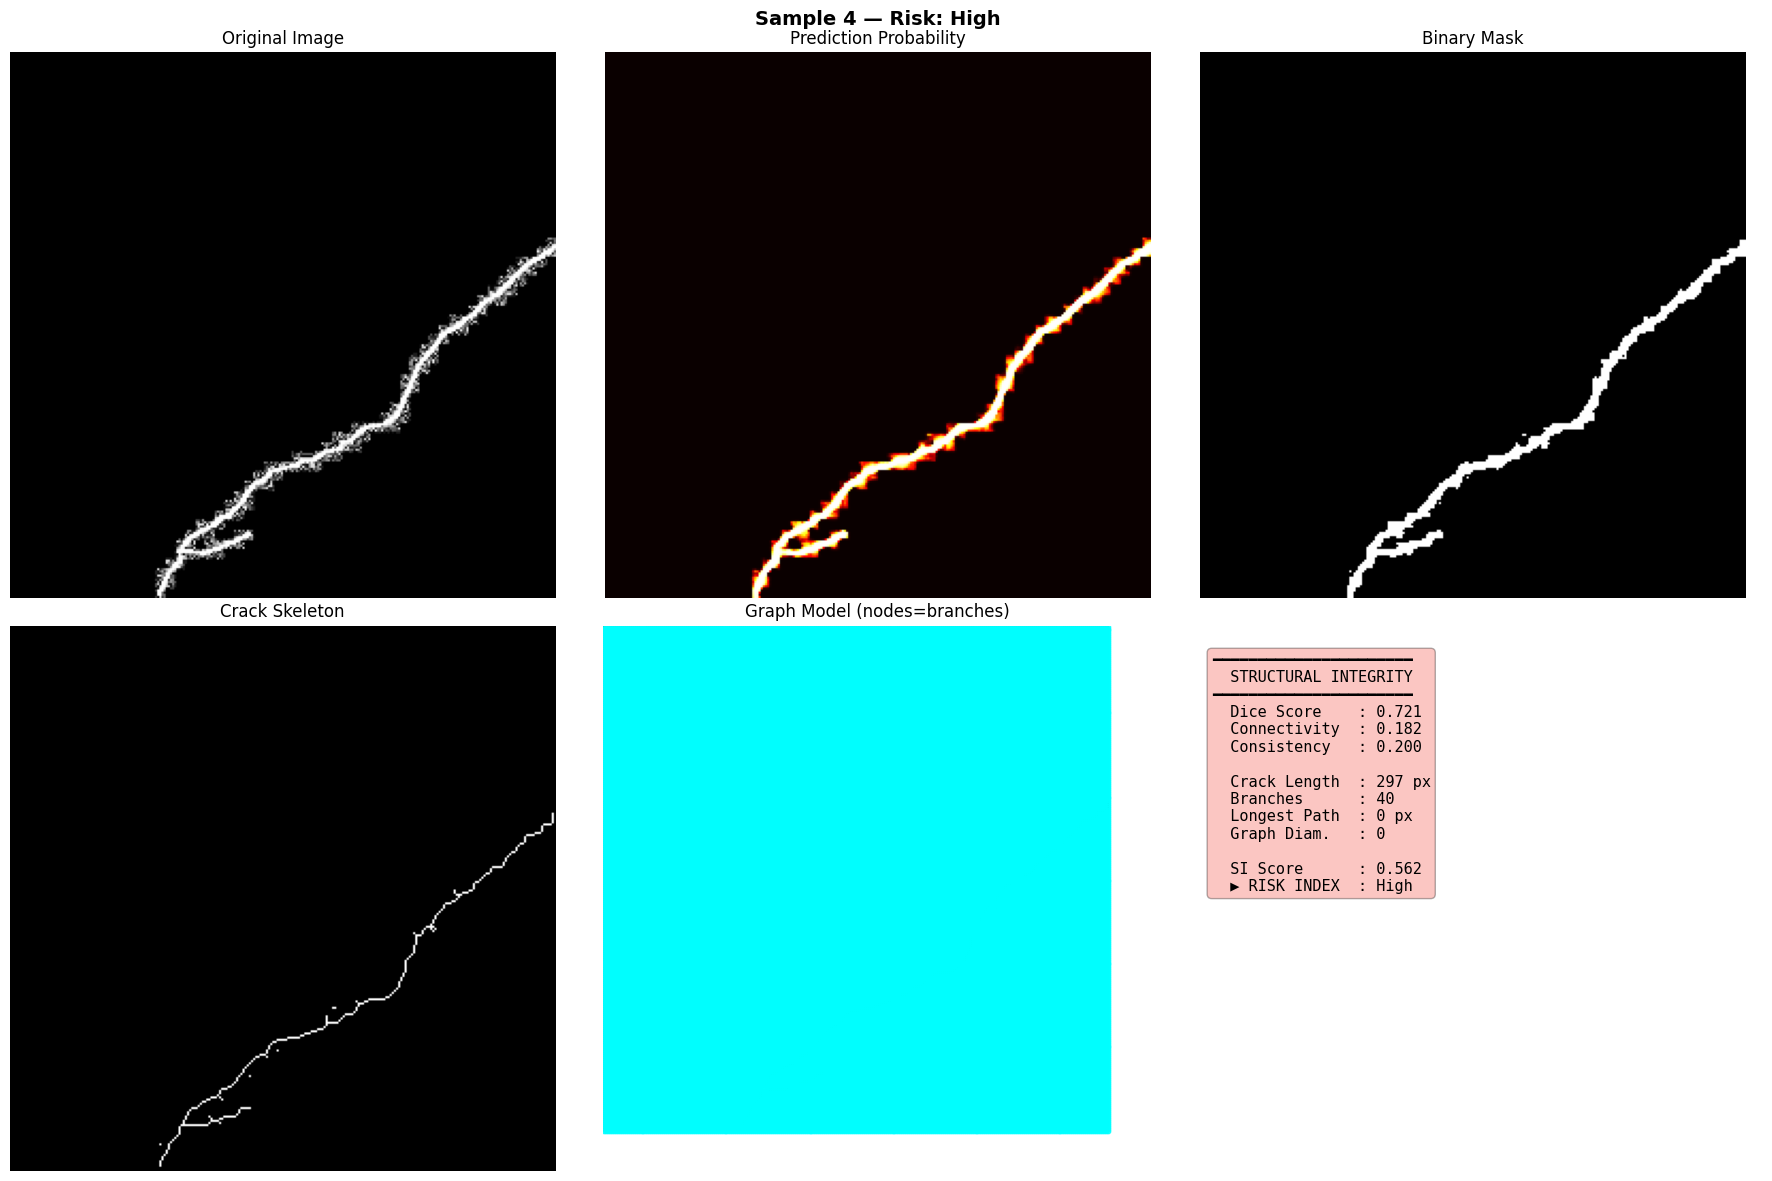

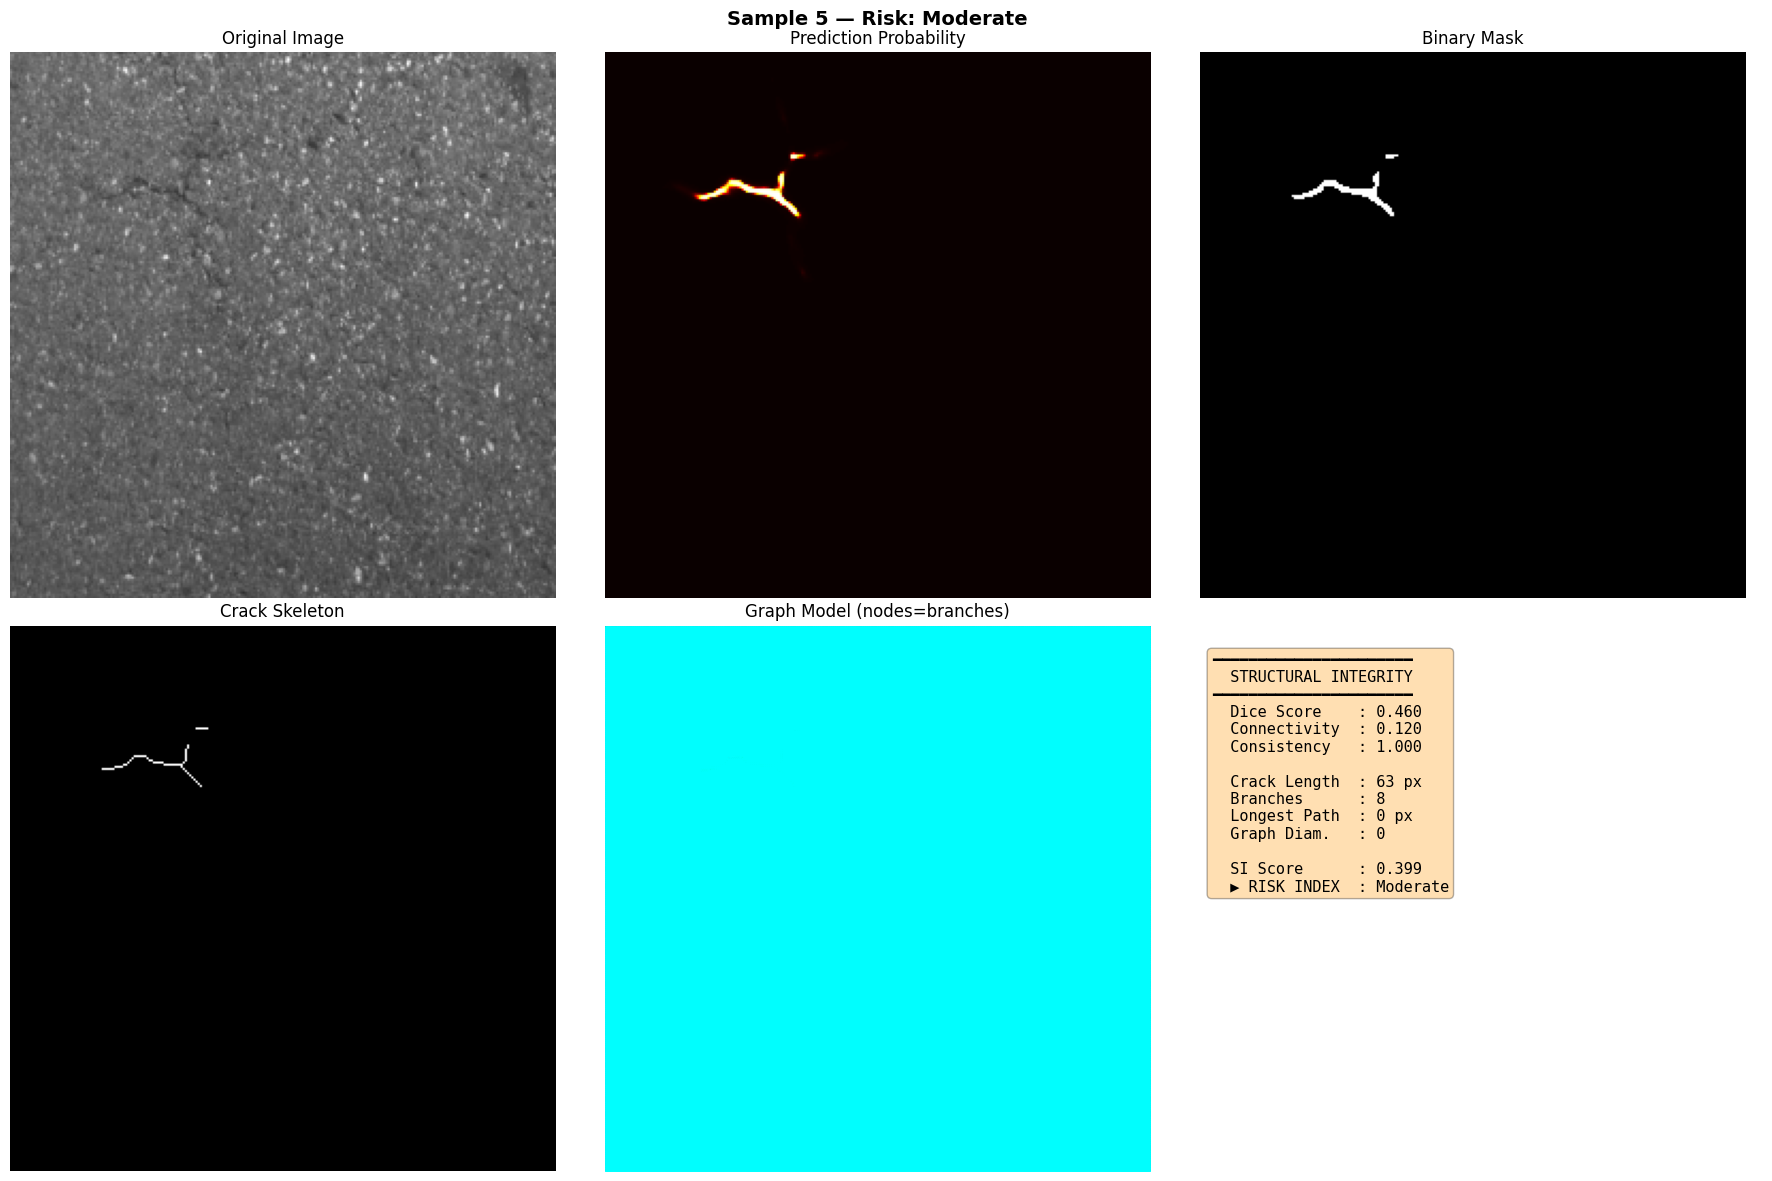

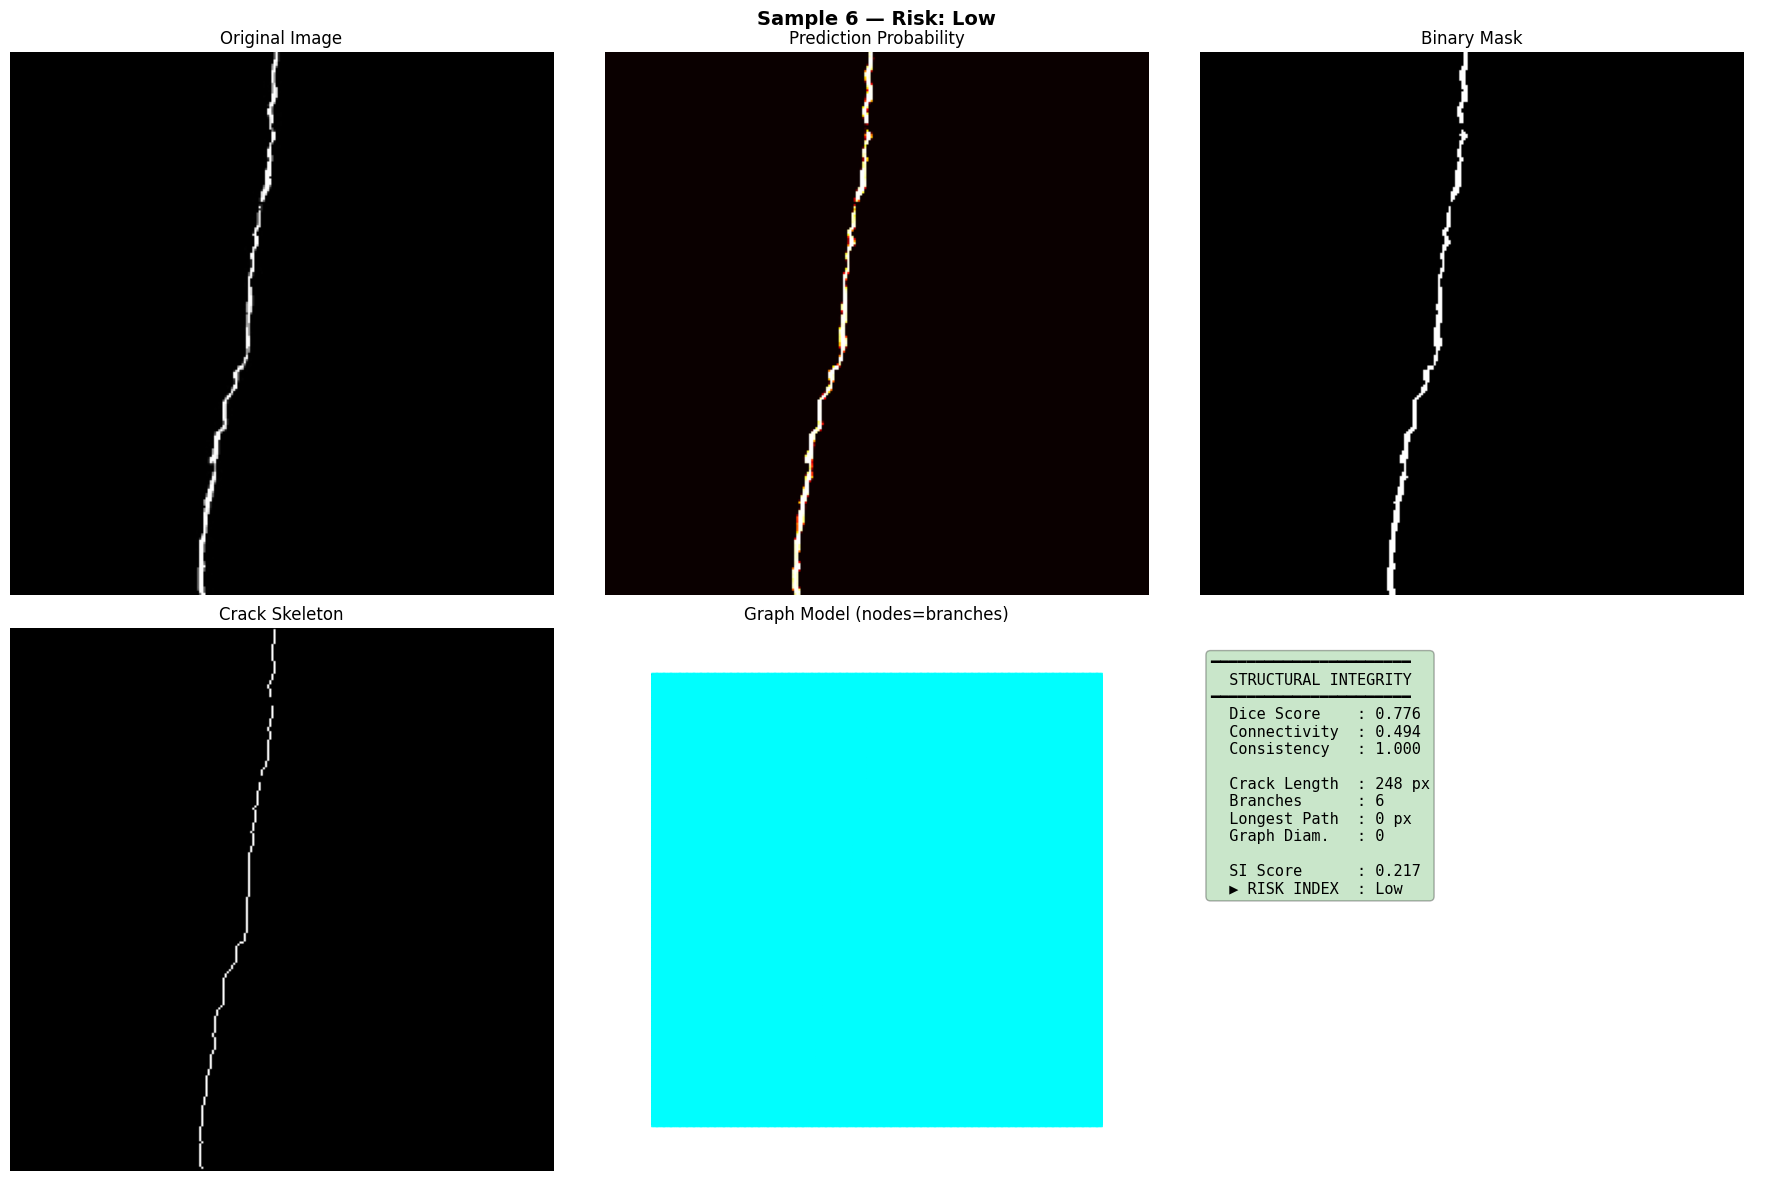

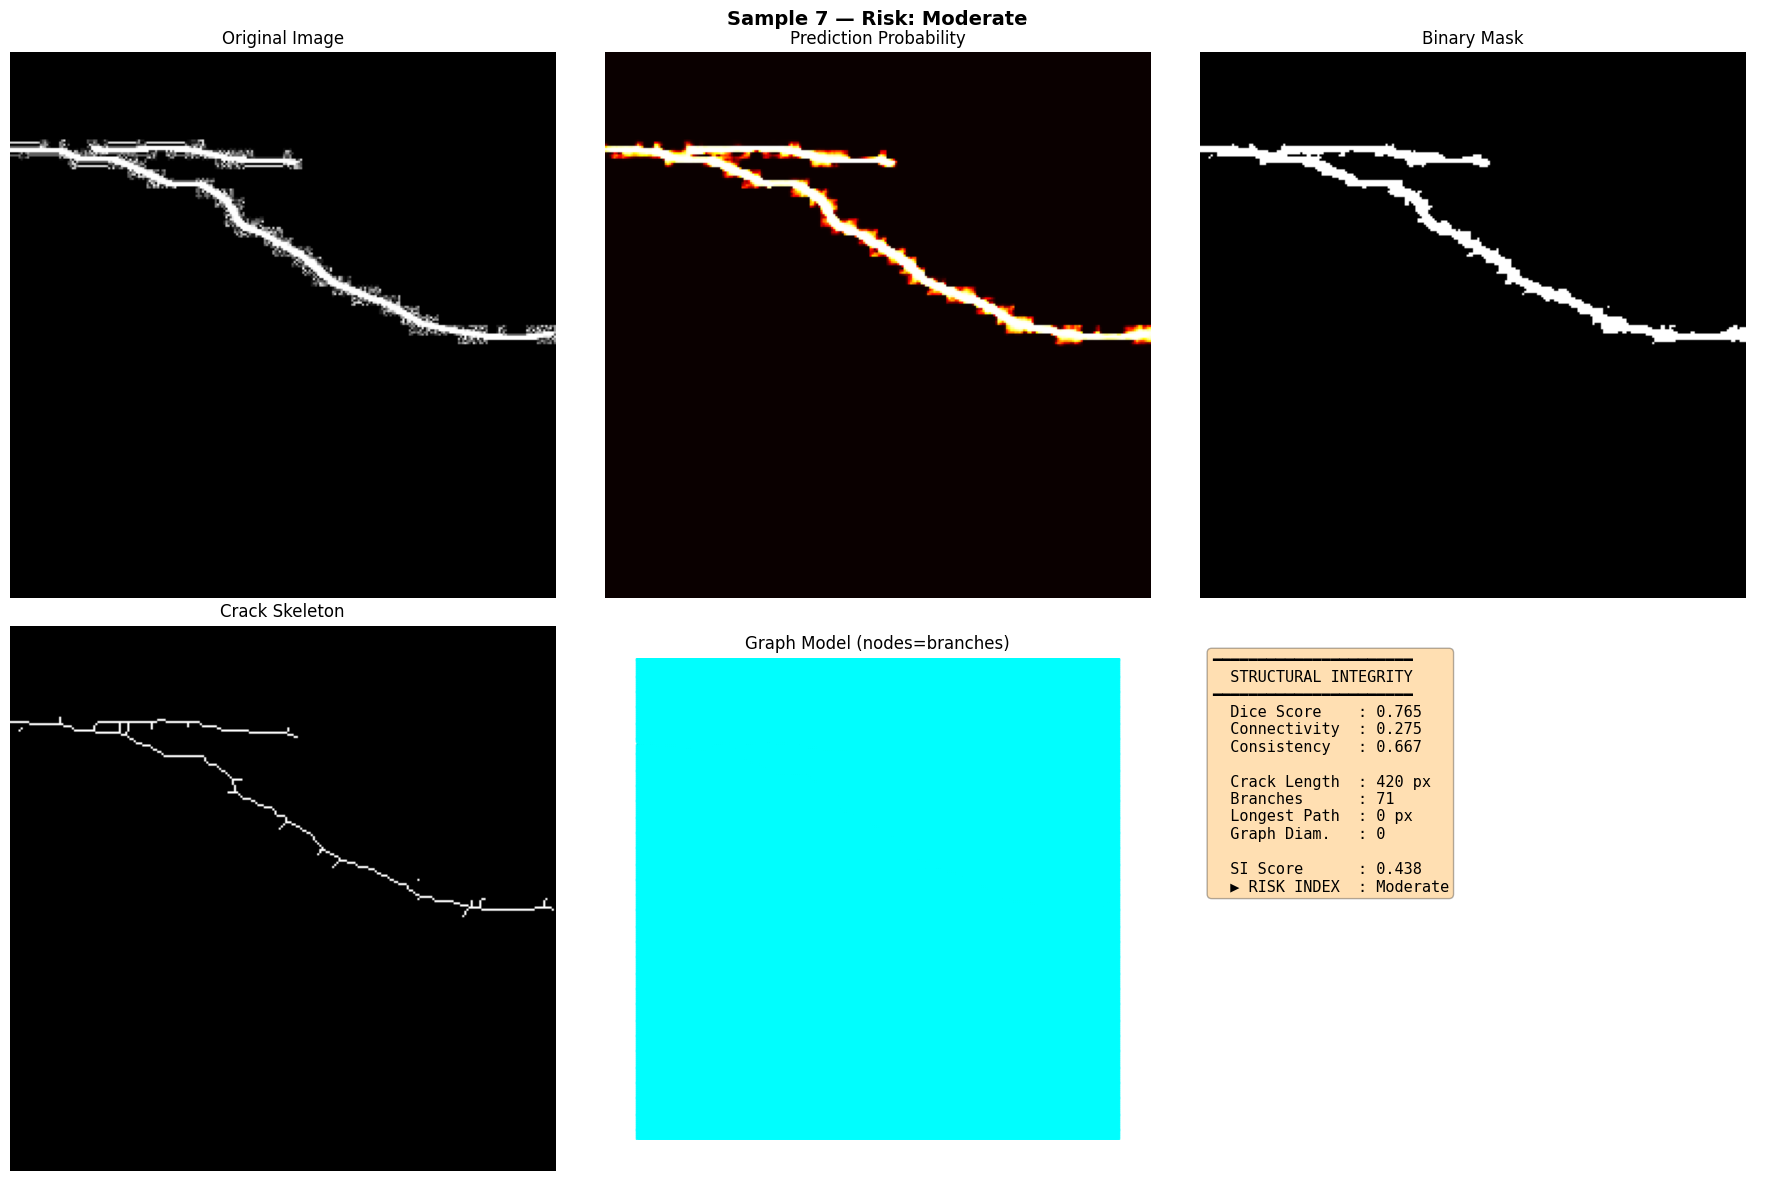

In [ ]:

RISK_COLORS = {"Low": "#4CAF50", "Moderate": "#FF9800",
               "High": "#F44336", "Critical": "#9C27B0"}

def visualise_result(res: dict, title: str = "", save_path: str = None):
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    si  = res["si_result"]
    col = RISK_COLORS[si["risk_index"]]

    # Row 1
    axes[0,0].imshow(res["image"]); axes[0,0].set_title("Original Image", fontsize=12); axes[0,0].axis("off")
    axes[0,1].imshow(res["pred_prob"], cmap="hot"); axes[0,1].set_title("Prediction Probability", fontsize=12); axes[0,1].axis("off")
    axes[0,2].imshow(res["pred_bin"], cmap="gray"); axes[0,2].set_title("Binary Mask", fontsize=12); axes[0,2].axis("off")

    # Row 2 – skeleton
    axes[1,0].imshow(res["skeleton"], cmap="gray"); axes[1,0].set_title("Crack Skeleton", fontsize=12); axes[1,0].axis("off")

    # Graph overlay
    G  = res["graph"]
    ax = axes[1,1]
    ax.imshow(res["skeleton"], cmap="gray")
    if G.number_of_nodes() > 0:
        pos = nx.get_node_attributes(G, "pos")
        nx.draw_networkx_nodes(G, pos=pos, ax=ax, node_size=10,
                               node_color="cyan", alpha=0.8)
        nx.draw_networkx_edges(G, pos=pos, ax=ax, width=0.8,
                               edge_color="lime", alpha=0.6)
    ax.set_title("Graph Model (nodes=branches)", fontsize=12); ax.axis("off")

    # SI dashboard
    ax = axes[1,2]; ax.axis("off")
    metrics_text = (
        f"━━━━━━━━━━━━━━━━━━━━━━\n"
        f"  STRUCTURAL INTEGRITY\n"
        f"━━━━━━━━━━━━━━━━━━━━━━\n"
        f"  Dice Score    : {si['dice_score']:.3f}\n"
        f"  Connectivity  : {si['connectivity']:.3f}\n"
        f"  Consistency   : {si['consistency']:.3f}\n"
        f"\n"
        f"  Crack Length  : {res['features']['total_crack_length_px']} px\n"
        f"  Branches      : {res['features']['num_branches']}\n"
        f"  Longest Path  : {res['features']['longest_path_px']} px\n"
        f"  Graph Diam.   : {res['features']['graph_diameter']}\n"
        f"\n"
        f"  SI Score      : {si['si_score']:.3f}\n"
        f"  ▶ RISK INDEX  : {si['risk_index']}"
    )
    ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes,
            fontsize=11, verticalalignment="top", fontfamily="monospace",
            bbox=dict(boxstyle="round", facecolor=col, alpha=0.3))

    fig.suptitle(title or "Crack Analysis Report",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()

# Run on test samples
import random

sample_pairs = random.sample(test_pairs, 8)

for i, (img_p, mask_p) in enumerate(sample_pairs):
    res = analyse_single_image(str(img_p), str(mask_p))
    test_results_full.append(res)

    visualise_result(
        res,
        title=f"Sample {i+1} — Risk: {res['si_result']['risk_index']}",
        save_path=str(cfg.VIZ_DIR / f"result_{i+1}.png")
    )

## Aggregate Results Table

In [60]:

rows = []
for i, (res, (img_p, _)) in enumerate(zip(test_results_full, test_pairs[:8])):
    row = {"sample": Path(img_p).name}
    row.update(res["features"])
    row.update(res["si_result"])
    rows.append(row)

df = pd.DataFrame(rows)
print("\n── Aggregate Structural Analysis ─────────────────────")
print(df[["sample","total_crack_length_px","num_branches",
          "longest_path_px","graph_diameter","si_score","risk_index"]].to_string(index=False))

df.to_csv(cfg.WORK_DIR / "structural_analysis.csv", index=False)



── Aggregate Structural Analysis ─────────────────────
                                                 sample  total_crack_length_px  num_branches  longest_path_px  graph_diameter  si_score risk_index
                 CRACK500_20160405_172849_1281_1081.jpg                    266             7                0               0    0.3251   Moderate
  Rissbilder_for_Florian_9S6A2912_19_2062_3738_2983.jpg                    290             9                0               0    0.1453        Low
                 Volker_DSC01626_757_1195_1027_1063.jpg                     91             3                0               0    0.3199   Moderate
Rissbilder_for_Florian_9S6A2806_2724_1289_2442_1975.jpg                    116             7                0               0    0.2492        Low
          noncrack_noncrack_concrete_wall_76_59.jpg.jpg                    301            46                0               0    0.3559   Moderate
                  CRACK500_20160330_170504_1281_361.jpg       

## Risk Distribution

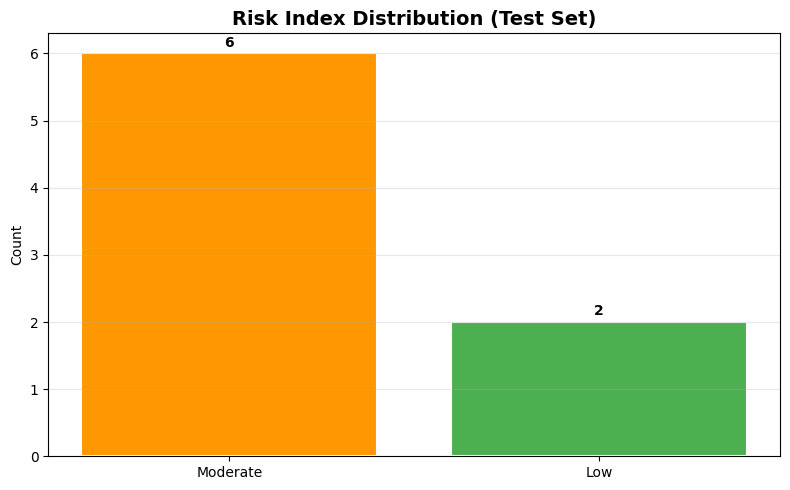

In [61]:

risk_counts = df["risk_index"].value_counts()
colors      = [RISK_COLORS.get(r, "#999") for r in risk_counts.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(risk_counts.index, risk_counts.values, color=colors, edgecolor="white", linewidth=1.5)
for bar, v in zip(bars, risk_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(v), ha="center", fontweight="bold")
ax.set_title("Risk Index Distribution (Test Set)", fontsize=14, fontweight="bold")
ax.set_ylabel("Count"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(cfg.VIZ_DIR / "risk_distribution.png", dpi=120)
plt.show()


## SI Score Histogram

In [40]:

# Compute SI for all test samples
all_si = []
model.eval()
with torch.no_grad():
    for imgs, masks in tqdm(test_dl, desc="Full test SI"):
        logits = model(imgs.to(DEVICE)).cpu()
        for j in range(logits.size(0)):
            logit_np = logits[j].numpy()
            mask_np  = masks[j].numpy()
            pred_bin = (1/(1+np.exp(-logit_np)) > 0.5).astype(np.uint8)
            skel     = skeletonize_mask(pred_bin)
            G        = build_crack_graph(skel)
            feats    = extract_structural_features(G, skel)
            si       = compute_si_score(logit_np, mask_np, feats)
            all_si.append(si)

si_scores = [s["si_score"] for s in all_si]
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(si_scores, bins=30, color="#2196F3", edgecolor="white", alpha=0.8)
for label_name, thresh in cfg.RISK_THRESHOLDS.items():
    ax.axvline(thresh, linestyle="--", linewidth=1.5,
               color=list(RISK_COLORS.values())[list(RISK_COLORS.keys()).index(
                   {"Low":"Moderate","Moderate":"High","High":"Critical"}[label_name])])
ax.set_xlabel("SI Score"); ax.set_ylabel("Count")
ax.set_title("Structural Integrity Score Distribution — Full Test Set", fontsize=13, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(cfg.VIZ_DIR / "si_histogram.png", dpi=120)
plt.show()


Full test SI:   0%|          | 0/283 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Summary

In [64]:

print("\n" + "="*60)
print("         FINAL MODEL SUMMARY")
print("="*60)
print(f"  Architecture   : Hybrid CNN-Transformer (UNet++)")
print(f"  Encoder        : {cfg.ENCODER}")
print(f"  Image Size     : {cfg.IMG_SIZE}×{cfg.IMG_SIZE}")
print(f"  Total Params   : {total_p/1e6:.2f} M")
print()
print("  Test Metrics:")
for k, v in test_results.items():
    print(f"    {k:<14}: {v:.4f}")
print()
print("  SI Score Stats:")
print(f"    Mean     : {np.mean(si_scores):.4f}")
print(f"    Std      : {np.std(si_scores):.4f}")
print(f"    Min      : {np.min(si_scores):.4f}")
print(f"    Max      : {np.max(si_scores):.4f}")

risk_dist = pd.Series([s["risk_index"] for s in all_si]).value_counts()
print("\n  Risk Distribution:")
for r, c in risk_dist.items():
    print(f"    {r:<10}: {c} ({c/len(all_si)*100:.1f}%)")
print("="*60)
print(f"\nAll outputs saved to: {cfg.WORK_DIR}")



         FINAL MODEL SUMMARY
  Architecture   : Hybrid CNN-Transformer (UNet++)
  Encoder        : resnet34
  Image Size     : 256×256
  Total Params   : 39.21 M

  Test Metrics:
    dice          : 0.8136
    iou           : 0.6887
    precision     : 0.8109
    recall        : 0.8184
    f1            : 0.8136

  SI Score Stats:


NameError: name 'si_scores' is not defined